In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
import numpy as np
from scipy.stats import ks_2samp

In [2]:

directory = "../extracted_randomPixel"
all_data = []
file_count = 0

for filename in os.listdir(directory):
    if filename.endswith(".txt"):
        file_count += 1
        if file_count == 16:
            print(f"Skipping file {file_count} ({filename}) as requested")
            continue
        file_path = os.path.join(directory, filename)
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            numeric_data = [line.strip().split() for line in lines if not line.startswith("MSG")]
            if numeric_data:
                df = pd.DataFrame(numeric_data)
                df.columns = [f"col_{i}" for i in range(len(df.iloc[0]))]
                df = df.apply(pd.to_numeric, errors='coerce')
                all_data.append(df)

print(f"Total files loaded: {len(all_data)}")
for i, df in enumerate(all_data):
    print(f"File {i+1}: Shape = {df.shape}")
print("\nFirst 5 rows of first dataset:")
print(all_data[0].head())

# Initialize lists for data processing
time = []
x_left = []
y_left = []
pupil_size_left = []
x_right = []
y_right = []
pupil_size_right = []
category_left = []
category_right = []
fixation = []
saccade = []
velocity_left = []
velocity_right = []
acceleration_left = []
acceleration_right = []
filtered_x_left = []
filtered_y_left = []
filtered_x_right = []
filtered_y_right = []
filtered_time = []
filtered_saccade = []
filtered_fixation = []
filtered_category_left = []
filtered_category_right = []
remove_nanbefore = 300
for i in range(len(all_data)):
    arr = np.swapaxes(np.array(all_data[i]), 0, 1)
    time.append(arr[0])
    x_left.append(arr[1])
    y_left.append(arr[2])
    pupil_size_left.append(arr[3])
    x_right.append(arr[4])
    y_right.append(arr[5])
    pupil_size_right.append(arr[6])
    category_left.append(arr[8])
    category_right.append(arr[9])
    
    fixation.append(np.where(category_left[-1] == 1, 1, 0))
    saccade.append(np.where(category_left[-1] == 2, 1, 0))
    
    # Filter NaN sequences
    Nan_array = (np.logical_not(np.isnan(x_left[-1])) & 
                 np.logical_not(np.isnan(y_left[-1])) &
                 np.logical_not(np.isnan(x_right[-1])) & 
                 np.logical_not(np.isnan(y_right[-1])))
    new_nan_array = Nan_array.copy()
    for j in range(1, remove_nanbefore):
        if j < len(new_nan_array):
            new_nan_array[:-j] *= Nan_array[j:]
    Nan_array = new_nan_array
    for j in range(1, remove_nanbefore):
        if j < len(new_nan_array):
            new_nan_array[j:] *= Nan_array[:-j]
    Nan_array = new_nan_array
    valid_indices = np.where(Nan_array)[0]  
    filtered_x_left.append(x_left[-1][valid_indices])
    filtered_y_left.append(y_left[-1][valid_indices])
    filtered_x_right.append(x_right[-1][valid_indices])
    filtered_y_right.append(y_right[-1][valid_indices])
    filtered_time.append(time[-1][valid_indices])
    filtered_category_left.append(category_left[-1][valid_indices])
    filtered_category_right.append(category_right[-1][valid_indices])
    filtered_saccade.append(saccade[-1][valid_indices])
    filtered_fixation.append(fixation[-1][valid_indices])
    
    # Compute velocities and accelerations
    dt = 1/1000
    delta_xpl = np.diff(x_left[-1])
    delta_ypl = np.diff(y_left[-1])
    delta_xpr = np.diff(x_right[-1])
    delta_ypr = np.diff(y_right[-1])
    distances_left = np.sqrt(delta_xpl**2 + delta_ypl**2)
    distances_right = np.sqrt(delta_xpr**2 + delta_ypr**2)
    v_left = distances_left / dt
    v_right = distances_right / dt
    velocity_left.append(v_left)
    velocity_right.append(v_right)
    
    a_left = np.diff(v_left) / dt
    a_right = np.diff(v_right) / dt
    acceleration_left.append(a_left)
    acceleration_right.append(a_right)

# Concatenate filtered data
filtered_category_right = np.concatenate(filtered_category_right)
filtered_x_right = np.concatenate(filtered_x_right)
filtered_y_right = np.concatenate(filtered_y_right)
filtered_category_left = np.concatenate(filtered_category_left)
filtered_x_left = np.concatenate(filtered_x_left)
filtered_y_left = np.concatenate(filtered_y_left)
filtered_saccade = np.concatenate(filtered_saccade)
filtered_fixation = np.concatenate(filtered_fixation)
filtered_time = np.concatenate(filtered_time)

# Compute common fixation and saccade points
common_fix_indices = np.where((filtered_category_left == 1) & (filtered_category_right == 1))[0]
common_x_fix_left = filtered_x_left[common_fix_indices]
common_x_fix_right = filtered_x_right[common_fix_indices]
common_y_fix_left = filtered_y_left[common_fix_indices]
common_y_fix_right = filtered_y_right[common_fix_indices]
common_fixation_count = len(common_fix_indices)
if common_fixation_count > 0:
    fix_x_y_left_corr = np.corrcoef(common_x_fix_left, common_y_fix_left)[0, 1]
    fix_x_y_right_corr = np.corrcoef(common_x_fix_right, common_y_fix_right)[0, 1]
else:
    fix_x_y_left_corr = 0
    fix_x_y_right_corr = 0

common_sac_indices = np.where((filtered_category_left == 2) & (filtered_category_right == 2))[0]
common_x_sac_left = filtered_x_left[common_sac_indices]
common_x_sac_right = filtered_x_right[common_sac_indices]
common_y_sac_left = filtered_y_left[common_sac_indices]
common_y_sac_right = filtered_y_right[common_sac_indices]
common_saccade_count = len(common_sac_indices)
if common_saccade_count > 0:
    sac_x_y_left_corr = np.corrcoef(common_x_sac_left, common_y_sac_left)[0, 1]
    sac_x_y_right_corr = np.corrcoef(common_x_sac_right, common_y_sac_right)[0, 1]
else:
    sac_x_y_left_corr = 0
    sac_x_y_right_corr = 0


Total files loaded: 15
File 1: Shape = (180020, 10)
File 2: Shape = (180020, 10)
File 3: Shape = (180013, 10)
File 4: Shape = (180003, 10)
File 5: Shape = (180020, 10)
File 6: Shape = (180018, 10)
File 7: Shape = (180016, 10)
File 8: Shape = (180017, 10)
File 9: Shape = (180044, 10)
File 10: Shape = (180014, 10)
File 11: Shape = (180012, 10)
File 12: Shape = (180006, 10)
File 13: Shape = (180011, 10)
File 14: Shape = (180020, 10)
File 15: Shape = (180015, 10)

First 5 rows of first dataset:
         col_0  col_1  col_2  col_3  col_4  col_5  col_6  col_7  col_8  col_9
0  498388203.0  998.8  524.8  696.0  989.9  440.9  650.0    0.0    0.0    0.0
1  498388204.0  998.6  525.0  697.0  988.1  441.0  649.0    0.0    0.0    0.0
2  498388205.0  998.6  525.2  696.0  986.1  441.0  650.0    0.0    0.0    0.0
3  498388206.0  998.7  524.6  696.0  985.9  436.0  646.0    0.0    0.0    0.0
4  498388207.0  998.9  523.8  695.0  989.1  431.0  641.0    0.0    0.0    0.0


In [3]:
dx = np.diff(filtered_x_left)
dy = np.diff(filtered_y_left)
dt = np.diff(filtered_time)
dt = np.where(dt == 0, 1e-6, dt)  
point_disp = np.sqrt(dx**2 + dy**2)
point_velo = point_disp / dt

theta_np = []
for i in range(len(dx) - 1):
    vec1 = [dx[i], dy[i]]
    vec2 = [dx[i + 1], dy[i + 1]]
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 == 0 or norm2 == 0:
        theta_np.append(np.nan)
        continue
    unit1 = vec1 / norm1
    unit2 = vec2 / norm2
    dot_product = np.dot(unit1, unit2)
    dot_product = np.clip(dot_product, -1.0, 1.0)
    theta = np.abs(np.arccos(dot_product))
    theta_np.append(theta)

theta_np = np.array(theta_np)
valid_theta_indices = ~np.isnan(theta_np)
theta_np = theta_np[valid_theta_indices]
point_velo_eff = np.abs(point_velo[:-1][valid_theta_indices] * np.cos(theta_np))

x_val_corr = filtered_x_left[1:-1][valid_theta_indices]  
y_val_corr = filtered_y_left[1:-1][valid_theta_indices]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

def apply_idt(x_vals, y_vals, timestamps, x_threshold=25, y_threshold=25, dur_threshold=0.150):
    x_fix, y_fix = [], []
    x_sac, y_sac = [], []
    classifier = []
    temp_x_fix, temp_y_fix = [], []
    temp_timestamps = []
    s_point = 0
    for i in range(len(x_vals)):
        if i < s_point:
            continue
        temp_x_fix.append(x_vals[i])
        temp_y_fix.append(y_vals[i])
        temp_timestamps.append(timestamps[i])
        max_x = max(temp_x_fix)
        min_x = min(temp_x_fix)
        max_y = max(temp_y_fix)
        min_y = min(temp_y_fix)
        if (max_x - min_x) > x_threshold or (max_y - min_y) > y_threshold:
            dur = temp_timestamps[-1] - temp_timestamps[0] if len(temp_timestamps) > 1 else 0
            if dur >= dur_threshold and len(temp_x_fix) > 1:
                x_fix.extend(temp_x_fix[:-1])
                y_fix.extend(temp_y_fix[:-1])
                classifier.extend(["fixation"] * (len(temp_x_fix) - 1))
            else:
                x_sac.extend(temp_x_fix[:-1])
                y_sac.extend(temp_y_fix[:-1])
                classifier.extend(["saccade"] * (len(temp_x_fix) - 1))
            x_sac.append(x_vals[i])
            y_sac.append(y_vals[i])
            classifier.append("saccade")
            temp_x_fix = []
            temp_y_fix = []
            temp_timestamps = []
            s_point = i + 1
        if i == len(x_vals) - 1:
            dur = temp_timestamps[-1] - temp_timestamps[0] if len(temp_timestamps) > 1 else 0
            if dur >= dur_threshold:
                x_fix.extend(temp_x_fix)
                y_fix.extend(temp_y_fix)
                classifier.extend(["fixation"] * len(temp_x_fix))
            else:
                x_sac.extend(temp_x_fix)
                y_sac.extend(temp_y_fix)
                classifier.extend(["saccade"] * len(temp_x_fix))
    return {'x_fix': x_fix, 'y_fix': y_fix, 'x_sac': x_sac, 'y_sac': y_sac, 'classifier': classifier}

def compute_k_ratio(classifier):
    if len(classifier) == 0:
        return float('inf')
    P = sum(1 for c in classifier if c == "saccade") / len(classifier)
    if P == 0 or P == 1:
        return float('inf')
    p_ind = len(classifier) * P * (1 - P)
    p_emp = sum(classifier[j] != classifier[j + 1] for j in range(len(classifier) - 1))
    return p_emp / p_ind if p_ind != 0 else float('inf')

# I-VT Optimization
v_min_ivt = np.percentile(point_velo, 1)
v_max_ivt = np.percentile(point_velo, 98)
thresholds_ivt = np.linspace(v_min_ivt, v_max_ivt, 150)
k_ratios_ivt = []
for threshold in thresholds_ivt:
    classifier = ["fixation" if v < threshold else "saccade" for v in point_velo]
    k_ratios_ivt.append(compute_k_ratio(classifier))
ivt_min_idx = np.argmin(k_ratios_ivt)
ivt_optimal_threshold = thresholds_ivt[ivt_min_idx]

# I-AVT Optimization
v_min_avt = 0
v_max_avt = 24
thresholds_avt = np.linspace(v_min_avt, v_max_avt, 200)
k_ratios_avt = []
for threshold in thresholds_avt:
    classifier = ["fixation" if v < threshold else "saccade" for v in point_velo_eff]
    k_ratios_avt.append(compute_k_ratio(classifier))
iavt_min_idx = np.argmin(k_ratios_avt)
iavt_optimal_threshold = thresholds_avt[iavt_min_idx]

# I-DT Grid Search for Optimal Parameters
print("Starting grid search for optimal I-DT parameters...")
x_y_thresholds = np.linspace(5, 90, 10)  # Expanded range for better optimization
dur_thresh_values = np.linspace(0.05, 0.5, 5)  # Expanded range
best_k_ratio = float('inf')
best_params = {'x_y_threshold': None, 'dur_threshold': None}

for xy_th in x_y_thresholds:
    for dur_th in dur_thresh_values:
        idt_temp = apply_idt(filtered_x_left, filtered_y_left, filtered_time, xy_th, xy_th, dur_th)
        k_ratio = compute_k_ratio(idt_temp['classifier'])
        if k_ratio < best_k_ratio:
            best_k_ratio = k_ratio
            best_params = {'x_y_threshold': xy_th, 'dur_threshold': dur_th}

print(f"Optimal I-DT parameters: {best_params}")
sampling_rate = 1000 
fixed_duration_samples = int(best_params['dur_threshold'] * sampling_rate)

window_size = 10
disp_values = []
for i in range(len(filtered_x_left) - window_size):
    window_x = filtered_x_left[i:i+window_size]
    window_y = filtered_y_left[i:i+window_size]
    dispersion = (max(window_x) - min(window_x)) + (max(window_y) - min(window_y))
    disp_values.append(dispersion)

disp_values = np.array(disp_values)
d_min = np.percentile(disp_values, 1)
d_max = np.percentile(disp_values, 98)
thresholds_idt = np.linspace(d_min, d_max, 50)

k_ratios_idt = []
for threshold in thresholds_idt:
    classifier = ["saccade"] * len(disp_values)
    i = 0
    sac_count = 0
    while i < len(disp_values):
        if disp_values[i] < threshold:
            start = i
            while i < len(disp_values) and disp_values[i] < threshold:
                i += 1
            end = i
            if (end - start) >= fixed_duration_samples:
                for j in range(start, end):
                    classifier[j] = "fixation"
            else:
                for j in range(start, end):
                    classifier[j] = "saccade"
                    sac_count += 1
        else:
            sac_count += 1
            i += 1
    P = sac_count / len(classifier)
    p_ind = len(classifier) * P * (1 - P)
    p_emp = sum(classifier[j] != classifier[j+1] for j in range(len(classifier) - 1))
    k_ratio = p_emp / p_ind if p_ind != 0 else float('inf')
    k_ratios_idt.append(k_ratio)

idt_min_idx = np.argmin(k_ratios_idt)
idt_optimal_disp = thresholds_idt[idt_min_idx]
print(f"Optimal dispersion for plot (fixed dur samples {fixed_duration_samples}): {idt_optimal_disp:.2f}")

Starting grid search for optimal I-DT parameters...
Optimal I-DT parameters: {'x_y_threshold': np.float64(90.0), 'dur_threshold': np.float64(0.05)}
Optimal dispersion for plot (fixed dur samples 50): 10.22


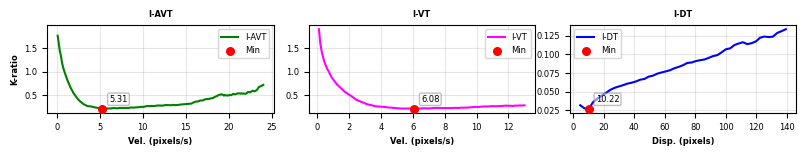

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 1.5))
ax2.sharey(ax1)
# I-AVT
ax1.plot(thresholds_avt, k_ratios_avt, c="green", linewidth=1.5, label="I-AVT")
ax1.scatter(thresholds_avt[iavt_min_idx], k_ratios_avt[iavt_min_idx],
            c="red", s=30, label="Min", zorder=5)
ax1.annotate(f"{iavt_optimal_threshold:.2f}",
             xy=(thresholds_avt[iavt_min_idx], k_ratios_avt[iavt_min_idx]),
             xytext=(5, 5), textcoords='offset points', fontsize=6,
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.5))
ax1.set_xlabel("Vel. (pixels/s)", fontsize=6, fontweight='bold')
ax1.set_ylabel("K-ratio", fontsize=6, fontweight='bold')
ax1.set_title("I-AVT", fontsize=6, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=6)
ax1.tick_params(axis='both', labelsize=6)

# I-VT
ax2.plot(thresholds_ivt, k_ratios_ivt, c="magenta", linewidth=1.5, label="I-VT")
ax2.scatter(thresholds_ivt[ivt_min_idx], k_ratios_ivt[ivt_min_idx],
            c="red", s=30, label="Min", zorder=5)
ax2.annotate(f"{ivt_optimal_threshold:.2f}",
             xy=(thresholds_ivt[ivt_min_idx], k_ratios_ivt[ivt_min_idx]),
             xytext=(5, 5), textcoords='offset points', fontsize=6,
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.5))
ax2.set_xlabel("Vel. (pixels/s)", fontsize=6, fontweight='bold')
ax2.set_title("I-VT", fontsize=6, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=6)
ax2.tick_params(axis='both', labelsize=6)

# I-DT (independent y-scale)
ax3.plot(thresholds_idt, k_ratios_idt, c="blue", linewidth=1.5, label="I-DT")
ax3.scatter(thresholds_idt[idt_min_idx], k_ratios_idt[idt_min_idx],
            c="red", s=30, label="Min", zorder=5)
ax3.annotate(f"{idt_optimal_disp:.2f}",
             xy=(thresholds_idt[idt_min_idx], k_ratios_idt[idt_min_idx]),
             xytext=(5, 5), textcoords='offset points', fontsize=6,
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.5))
ax3.set_xlabel("Disp. (pixels)", fontsize=6, fontweight='bold')
ax3.set_title("I-DT", fontsize=6, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=6)
ax3.tick_params(axis='both', labelsize=6)

plt.tight_layout(pad=0.5)
plt.savefig("k_ratio_RP.pdf", dpi=300, format='pdf', bbox_inches='tight')
plt.show()


In [6]:
# Print optimal thresholds and K-ratios with units

print(f"I-AVT: optimal angular velocity threshold = {iavt_optimal_threshold:.2f} rad/s, "
      f"K-ratio = {k_ratios_avt[iavt_min_idx]:.4f}")

print(f"I-VT: optimal velocity threshold = {ivt_optimal_threshold:.2f} pixels/s, "
      f"K-ratio = {k_ratios_ivt[ivt_min_idx]:.4f}")

print(f"I-DT: optimal dispersion threshold = {idt_optimal_disp:.2f} pixels, "
      f"K-ratio = {k_ratios_idt[idt_min_idx]:.4f}")


I-AVT: optimal angular velocity threshold = 5.31 rad/s, K-ratio = 0.2183
I-VT: optimal velocity threshold = 6.08 pixels/s, K-ratio = 0.2163
I-DT: optimal dispersion threshold = 10.22 pixels, K-ratio = 0.0272


In [7]:

def apply_ivt(point_velo, x_vals, y_vals, threshold):
    min_len = min(len(point_velo), len(x_vals), len(y_vals))
    point_velo = point_velo[:min_len]
    x_vals = x_vals[:min_len]
    y_vals = y_vals[:min_len]
    
    x_fix, y_fix = [], []
    x_sac, y_sac = [], []
    classifier = []
    for i in range(min_len):
        if 0 <= point_velo[i] < threshold:
            x_fix.append(x_vals[i])
            y_fix.append(y_vals[i])
            classifier.append("fixation")
        else:
            x_sac.append(x_vals[i])
            y_sac.append(y_vals[i])
            classifier.append("saccade")
    return {'x_fix': x_fix, 'y_fix': y_fix, 'x_sac': x_sac, 'y_sac': y_sac, 'classifier': classifier}

def apply_iavt(point_velo_eff, x_vals, y_vals, threshold):
    min_len = min(len(point_velo_eff), len(x_vals), len(y_vals))
    point_velo_eff = point_velo_eff[:min_len]
    x_vals = x_vals[:min_len]
    y_vals = y_vals[:min_len]
    
    x_fix, y_fix = [], []
    x_sac, y_sac = [], []
    classifier = []
    for i in range(min_len):
        if point_velo_eff[i] < threshold:
            x_fix.append(x_vals[i])
            y_fix.append(y_vals[i])
            classifier.append("fixation")
        else:
            x_sac.append(x_vals[i])
            y_sac.append(y_vals[i])
            classifier.append("saccade")
    return {'x_fix': x_fix, 'y_fix': y_fix, 'x_sac': x_sac, 'y_sac': y_sac, 'classifier': classifier}

def apply_idt(x_vals, y_vals, timestamps, x_threshold=25, y_threshold=25, dur_threshold=0.150):
    x_fix, y_fix = [], []
    x_sac, y_sac = [], []
    classifier = []
    
    temp_x_fix, temp_y_fix = [], []
    temp_timestamps = []
    
    s_point = 0
    for i in range(len(x_vals)):
        if i < s_point:
            continue
        
        temp_x_fix.append(x_vals[i])
        temp_y_fix.append(y_vals[i])
        temp_timestamps.append(timestamps[i])
        
        max_x = max(temp_x_fix)
        min_x = min(temp_x_fix)
        max_y = max(temp_y_fix)
        min_y = min(temp_y_fix)
        
        if (max_x - min_x) > x_threshold or (max_y - min_y) > y_threshold:
            dur = temp_timestamps[-1] - temp_timestamps[0] if len(temp_timestamps) > 1 else 0
            if dur >= dur_threshold and len(temp_x_fix) > 1:
                x_fix.extend(temp_x_fix[:-1])
                y_fix.extend(temp_y_fix[:-1])
                classifier.extend(["fixation"] * (len(temp_x_fix) - 1))
            else:
                x_sac.extend(temp_x_fix[:-1])
                y_sac.extend(temp_y_fix[:-1])
                classifier.extend(["saccade"] * (len(temp_x_fix) - 1))
            
            # Current point starts new potential fixation or saccade
            x_sac.append(x_vals[i])
            y_sac.append(y_vals[i])
            classifier.append("saccade")
            
            temp_x_fix = []
            temp_y_fix = []
            temp_timestamps = []
            s_point = i + 1
        if i == len(x_vals) - 1:
            # Handle last group
            dur = temp_timestamps[-1] - temp_timestamps[0] if len(temp_timestamps) > 1 else 0
            if dur >= dur_threshold:
                x_fix.extend(temp_x_fix)
                y_fix.extend(temp_y_fix)
                classifier.extend(["fixation"] * len(temp_x_fix))
            else:
                x_sac.extend(temp_x_fix)
                y_sac.extend(temp_y_fix)
                classifier.extend(["saccade"] * len(temp_x_fix))
    
    return {'x_fix': x_fix, 'y_fix': y_fix, 'x_sac': x_sac, 'y_sac': y_sac, 'classifier': classifier}

# Apply algorithms (align lengths for IVT and IAVT to point_velo and point_velo_eff)
length_ivt = len(point_velo)
length_iavt = len(point_velo_eff)
x_ivt = filtered_x_left[:length_ivt]
y_ivt = filtered_y_left[:length_ivt]
x_iavt = x_val_corr[:length_iavt]  # Aligned to effective velo
y_iavt = y_val_corr[:length_iavt]

ivt_results = apply_ivt(point_velo, x_ivt, y_ivt, ivt_optimal_threshold)
iavt_results = apply_iavt(point_velo_eff, x_iavt, y_iavt, iavt_optimal_threshold)
idt_results = apply_idt(filtered_x_left, filtered_y_left, filtered_time, 
                        best_params['x_y_threshold'], best_params['x_y_threshold'], best_params['dur_threshold'])

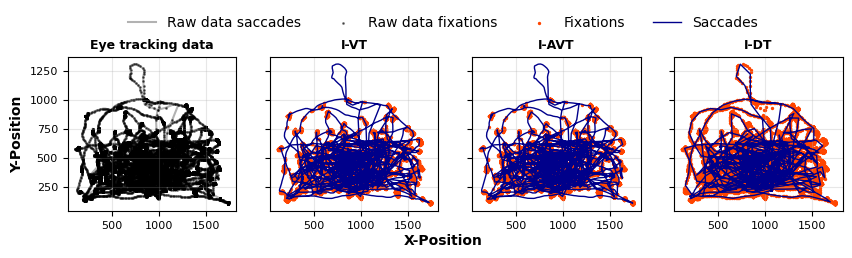

In [8]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 2), sharex=True, sharey=True)

axis_fs = 10

ax1.plot(filtered_x_left, filtered_y_left, 'k-', alpha=0.3)
ax1.scatter(filtered_x_left, filtered_y_left, s=1, c='black', alpha=0.5, marker='o')
ax1.set_ylabel("Y-Position", fontsize=axis_fs, fontweight='bold')
ax1.set_title("Eye tracking data", fontsize=9, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', labelsize=8)

ax2.scatter(ivt_results['x_fix'], ivt_results['y_fix'], s=2, c="#FF4500", alpha=1, marker='o')
ax2.plot(ivt_results['x_sac'], ivt_results['y_sac'], '-', color="#00008B", linewidth=1, alpha=1)
ax2.set_title("I-VT", fontsize=9, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', labelsize=8)

ax3.plot(iavt_results['x_sac'], iavt_results['y_sac'], '-', color="#00008B", linewidth=1, alpha=1)
ax3.scatter(iavt_results['x_fix'], iavt_results['y_fix'], s=2, c="#FF4500", alpha=1, marker='o')
ax3.set_title("I-AVT", fontsize=9, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='both', labelsize=8)

ax4.scatter(idt_results['x_fix'], idt_results['y_fix'], s=2, c="#FF4500", alpha=1, marker='o')
ax4.plot(idt_results['x_sac'], idt_results['y_sac'], '-', color="#00008B", linewidth=1, alpha=1)
ax4.set_title("I-DT", fontsize=9, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='both', labelsize=8)

# single centered X-axis label with axis font size
fig.text(0.5, -0.06, 'X-Position', ha='center', fontsize=axis_fs, fontweight='bold')

# legend
fig.legend(['Raw data saccades', 'Raw data fixations', 'Fixations', 'Saccades'], 
           loc='upper center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, 1.15), frameon=False)

#plt.savefig("complete_algorithm_comparison_RP.png", dpi=600, bbox_inches='tight', pad_inches=0.05)
plt.show()


/tmp/ipykernel_19128/1727562562.py:102: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary_df = pd.concat([summary_df, pd.DataFrame([{


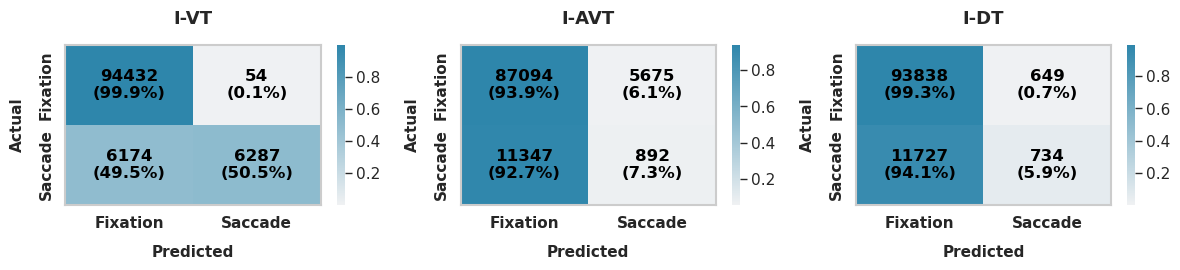

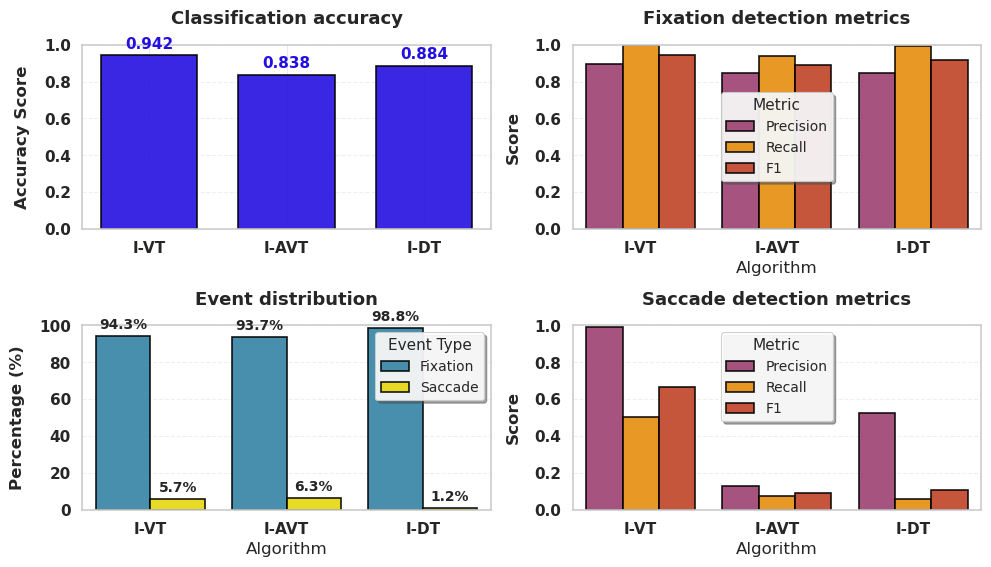


ALGORITHM PERFORMANCE SUMMARY
Algorithm  Accuracy  Precision (Fix)  Recall (Fix)  F1 (Fix)  Precision (Sac)  Recall (Sac)  F1 (Sac)  Fixation %  Saccade %
     I-VT    0.9418           0.8940        0.9994    0.9438           0.9907        0.5045    0.6686     94.3327     5.6673
    I-AVT    0.8379           0.8447        0.9388    0.8893           0.1287        0.0729    0.0931     93.7012     6.2988
     I-DT    0.8843           0.8486        0.9931    0.9152           0.5262        0.0589    0.1059     98.7542     1.2458


In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore", message="Passing `palette` without assigning `hue` is deprecated", category=FutureWarning)
warnings.filterwarnings("ignore", message="When grouping with a length-1 list-like, you will need to pass a length-1 tuple", category=FutureWarning)
warnings.filterwarnings("ignore", message="DataFrameGroupBy.apply operated on the grouping columns", category=FutureWarning)

# ---------- professional styling helpers ----------
def bold_ticks(ax, size=11, weight="bold"):
    ax.tick_params(axis='both', which='both', labelsize=size, width=1.5)
    for lbl in ax.get_xticklabels():
        lbl.set_fontweight(weight)
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight(weight)

def set_xylabels(ax, xlabel=None, ylabel=None, size=12, weight="bold"):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=size, fontweight=weight, labelpad=10)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=size, fontweight=weight, labelpad=10)

def set_title(ax, title, size=14, weight="bold", pad=15):
    ax.set_title(title, fontsize=size, fontweight=weight, pad=pad)

def analyze_all_algorithms(ground_truth, ivt_results, iavt_results, idt_results):
    # Professional color scheme
    sns.set_theme(style="whitegrid", context="paper")
    plt.rcParams.update({
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "font.family": "DejaVu Sans",  # Professional, readable font
        "axes.linewidth": 1.2,
        "grid.linewidth": 0.8,
        "grid.alpha": 0.4
    })

    algorithms = {'I-VT': ivt_results, 'I-AVT': iavt_results, 'I-DT': idt_results}
    summary_df = pd.DataFrame(columns=[
        'Algorithm', 'Accuracy', 'Precision (Fix)', 'Recall (Fix)', 'F1 (Fix)',
        'Precision (Sac)', 'Recall (Sac)', 'F1 (Sac)', 'Fixation %', 'Saccade %'
    ])

    fig_cm, axs = plt.subplots(1, 3, figsize=(12, 3))

    # Professional color palette for confusion matrices
    cmap_cm = sns.light_palette("#2E86AB", as_cmap=True)
    
    for ax, (algo_name, results) in zip(axs, algorithms.items()):
        if 'classifier' not in results:
            ax.axis('off')
            ax.text(0.5, 0.5, 'No Data', transform=ax.transAxes, 
                   ha='center', va='center', fontsize=12, fontweight='bold')
            continue

        predictions = np.array([1 if cls == 'fixation' else 2 for cls in results['classifier']])
        L = min(len(ground_truth), len(predictions))
        y_true = ground_truth[:L]
        y_pred = predictions[:L]

        cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
        
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_normalized = np.nan_to_num(cm_normalized)
        
        annot = np.array([f"{count}\n({perc:.1%})" for count, perc in zip(cm.flatten(), cm_normalized.flatten())]).reshape(2, 2)
        
        sns.heatmap(
            cm_normalized, annot=annot, fmt='', cmap=cmap_cm, cbar=True, ax=ax,
            xticklabels=['Fixation', 'Saccade'], yticklabels=['Fixation', 'Saccade'],
            annot_kws={"size": 12, "weight": "bold", "color": "black"}#,
            #cbar_kws={'label': 'Normalized Proportion', 'shrink': 0.8}
        )
        
        set_title(ax, f"{algo_name}", size=13)
        set_xylabels(ax, "Predicted", "Actual", size=11, weight="bold")
        bold_ticks(ax, size=11, weight="bold")
        
        # Add border to each cell for clarity
        for _, spine in ax.spines.items():
            spine.set_visible(True)
            spine.set_linewidth(1.5)

        report = classification_report(
            y_true, y_pred, target_names=['Fixation', 'Saccade'],
            labels=[1, 2], output_dict=True, zero_division=0
        )

        accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum() if cm.sum() > 0 else 0.0
        fix_count = int(np.sum(y_pred == 1))
        sac_count = int(np.sum(y_pred == 2))
        total = max(fix_count + sac_count, 1)
        fix_percent = 100.0 * fix_count / total
        sac_percent = 100.0 * sac_count / total

        summary_df = pd.concat([summary_df, pd.DataFrame([{
            'Algorithm': algo_name,
            'Accuracy': accuracy,
            'Precision (Fix)': report['Fixation']['precision'],
            'Recall (Fix)': report['Fixation']['recall'],
            'F1 (Fix)': report['Fixation']['f1-score'],
            'Precision (Sac)': report['Saccade']['precision'],
            'Recall (Sac)': report['Saccade']['recall'],
            'F1 (Sac)': report['Saccade']['f1-score'],
            'Fixation %': fix_percent,
            'Saccade %': sac_percent
        }])], ignore_index=True)

    plt.tight_layout(rect=[0, 0, 1, 0.93])  # Make room for suptitle
    plt.show(fig_cm, "algorithm_confusion_matrices_RP")

    summary_df['Algorithm'] = pd.Categorical(summary_df['Algorithm'],
                                             categories=['I-VT', 'I-AVT', 'I-DT'],
                                             ordered=True)
    summary_df = summary_df.sort_values('Algorithm')

    # Professional color palette
    professional_palette = {
        'accuracy': "#240FE2",      
        'precision': '#A23B72',     # Elegant purple
        'recall': '#F18F01',        # Warm orange
        'f1': '#C73E1D',           # Rich red
        'fixation': '#2E86AB',     # Blue
        'saccade': "#F1E101"       # Orange
    }
    
    # Fixed palette dictionaries with cleaned names
    PAL_FIX = {"Precision": professional_palette['precision'], 
               "Recall": professional_palette['recall'], 
               "F1": professional_palette['f1']}
    
    PAL_SAC = {"Precision": professional_palette['precision'], 
               "Recall": professional_palette['recall'], 
               "F1": professional_palette['f1']}
    
    PAL_EVT = {"Fixation": professional_palette['fixation'], 
               "Saccade": professional_palette['saccade']}

    fig_metrics = plt.figure(figsize=(10, 6))

    ax1 = plt.subplot(2, 2, 1)
    x = np.arange(len(summary_df))
    vals = summary_df['Accuracy'].astype(float).to_numpy()
    
    bars = ax1.bar(x, vals, color=professional_palette['accuracy'], 
                   edgecolor='black', linewidth=1.2, alpha=0.9, width=0.7)
    ax1.set_xticks(x)
    ax1.set_xticklabels(summary_df['Algorithm'], fontweight='bold')
    set_title(ax1, 'Classification accuracy', size=13)
    set_xylabels(ax1, None, "Accuracy Score", size=12, weight="bold")
    ax1.set_ylim(0, 1)
    ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
    bold_ticks(ax1, size=11, weight="bold")
    
    # Value annotations on bars
    for bar, v in zip(bars, vals):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02, 
                f"{v:.3f}", ha='center', va='bottom', 
                fontsize=11, fontweight="bold", color=professional_palette['accuracy'])

    ax2 = plt.subplot(2, 2, 2)
    fix_df = summary_df.melt(id_vars=['Algorithm'],
                             value_vars=['Precision (Fix)', 'Recall (Fix)', 'F1 (Fix)'],
                             var_name='Metric', value_name='Value')
    
    fix_df['Metric'] = fix_df['Metric'].str.replace(' (Fix)', '', regex=False)
    
    sns.barplot(x='Algorithm', y='Value', hue='Metric', data=fix_df,
                palette=PAL_FIX, edgecolor='black', linewidth=1.2,
                errorbar=None, ax=ax2, alpha=0.9, saturation=0.9)
    set_title(ax2, 'Fixation detection metrics', size=13)
    set_xylabels(ax2, None, "Score", size=12, weight="bold")
    ax2.set_ylim(0, 1)
    ax2.grid(True, axis='y', alpha=0.3, linestyle='--')
    bold_ticks(ax2, size=11, weight="bold")
    ax2.legend(title='Metric', frameon=True, fancybox=True, 
              shadow=True, framealpha=0.9, loc='center', fontsize=10, title_fontsize=11)
    
    ax4 = plt.subplot(2, 2, 3)
    evt_df = summary_df.melt(id_vars=['Algorithm'],
                             value_vars=['Fixation %', 'Saccade %'],
                             var_name='Event Type', value_name='Percentage')
    
    evt_df['Event Type'] = evt_df['Event Type'].str.replace(' %', '', regex=False)
    
    sns.barplot(x='Algorithm', y='Percentage', hue='Event Type', data=evt_df,
                palette=PAL_EVT, edgecolor='black', linewidth=1.2,
                errorbar=None, ax=ax4, alpha=0.9, saturation=0.9)
    set_title(ax4, 'Event distribution', size=13)
    set_xylabels(ax4, None, "Percentage (%)", size=12, weight="bold")
    ax4.set_ylim(0, 100)
    ax4.grid(True, axis='y', alpha=0.3, linestyle='--')
    bold_ticks(ax4, size=11, weight="bold")
    ax4.legend(title='Event Type', frameon=True, fancybox=True, 
              shadow=True, framealpha=0.9, fontsize=10, title_fontsize=11)
    
    for container in ax4.containers:
        ax4.bar_label(container, fmt="%.1f%%", fontsize=10, fontweight="bold", padding=3)

    # Saccade metrics
    ax3 = plt.subplot(2, 2, 4)
    sac_df = summary_df.melt(id_vars=['Algorithm'],
                             value_vars=['Precision (Sac)', 'Recall (Sac)', 'F1 (Sac)'],
                             var_name='Metric', value_name='Value')
    
    sac_df['Metric'] = sac_df['Metric'].str.replace(' (Sac)', '', regex=False)
    
    sns.barplot(x='Algorithm', y='Value', hue='Metric', data=sac_df,
                palette=PAL_SAC, edgecolor='black', linewidth=1.2,
                errorbar=None, ax=ax3, alpha=0.9, saturation=0.9)
    set_title(ax3, 'Saccade detection metrics', size=13)
    set_xylabels(ax3, None, "Score", size=12, weight="bold")
    ax3.set_ylim(0, 1)
    ax3.grid(True, axis='y', alpha=0.3, linestyle='--')
    bold_ticks(ax3, size=11, weight="bold")
    ax3.legend(title='Metric', frameon=True, fancybox=True, 
              shadow=True, framealpha=0.9, fontsize=10, title_fontsize=11)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("algorithm_performance_metrics_RP.pdf", dpi=300, format='pdf', bbox_inches='tight')
    plt.show(fig_metrics, "algorithm_performance_metrics")

    print("\n" + "="*60)
    print("ALGORITHM PERFORMANCE SUMMARY")
    print("="*60)
    print(summary_df.round(4).to_string(index=False))
    print("="*60)

    return summary_df

summary = analyze_all_algorithms(filtered_category_left, ivt_results, iavt_results, idt_results)
